## 1 Ejercicio

Implemente una función:

```python
bfs_8_puzzle(estado_inicial, estado_objetivo)
```

que devuelva:

- El camino desde el estado inicial hasta el objetivo.
- El número de movimientos.
- La cantidad de estados explorados.

### Restricciones

- Utilice BFS.
- Evite visitar dos veces el mismo estado.
- No utilice ninguna heurística.

> **Pregunta:** ¿Qué problema aparece cuando el estado inicial se encuentra muy lejos del objetivo?

In [89]:
# TODO: implemente aquí BFS para el 8-puzzle.

def bfs_8_puzzle(estado_inicial, estado_objetivo):
    pass

In [90]:
import matplotlib.pyplot as plt
from collections import deque

# 1.1. Taller para estudiar

1. Modifique el orden de los movimientos del laberinto y compare el comportamiento de DFS.
2. Construya un laberinto de al menos `10 × 10` y compare BFS y DFS en:
   - longitud del camino,
   - estados explorados.
3. Modifique el problema de los recipientes para capacidades diferentes y determine si existe solución.
4. Complete la implementación BFS del 8-puzzle.
5. Explique, con sus propias palabras, por qué BFS y DFS se consideran algoritmos de búsqueda **no informada**.

### Uso de IA generativa

Si utiliza una herramienta de IA generativa en esta actividad, indique:

- herramienta utilizada,
- propósito de uso,
- partes de la solución en las que fue empleada.

Recuerde: usted debe estar en capacidad de **explicar y defender completamente** el código y las respuestas entregadas.

In [91]:
#matriz del laberinto
laberinto = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
]

INICIO = (0, 0) #están en notación fila / columna
OBJETIVO = (4, 4)
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)] #lista de tuplas

In [92]:
def sucesores_laberinto(laberinto, posicion):
    filas = len(laberinto)
    columnas = len(laberinto[0])
    f, c = posicion

    sucesores = []

    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc

        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores

## 1.2 Resolver el laberinto con BFS

Además del camino, contabilizaremos cuántos estados fueron descubiertos.

In [93]:

def bfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    cola = deque([(inicio, [inicio])])
    visitados = {inicio}

    while cola:
        posicion, camino = cola.popleft()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in sucesores_laberinto(laberinto, posicion):
            if nuevo not in visitados:
                visitados.add(nuevo)
                cola.append((nuevo, camino + [nuevo]))

    return None


resultado_bfs = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_bfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 16}

## 1.3 Resolver el mismo laberinto con DFS

In [94]:
def dfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    pila = [(inicio, [inicio])]
    visitados = {inicio}

    while pila:
        posicion, camino = pila.pop()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in (sucesores_laberinto(laberinto, posicion)):
            if nuevo not in visitados:
                visitados.add(nuevo)
                pila.append((nuevo, camino + [nuevo]))

    return None


resultado_dfs = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_dfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 18}

## 1.4 Visualización del camino

La visualización permite comparar no solo si ambos algoritmos encuentran una solución, sino **qué tipo de camino producen**.

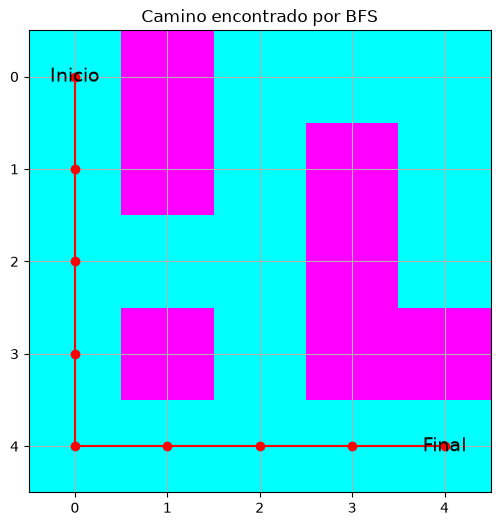

In [95]:
def mostrar_laberinto(laberinto, camino=None, inicio=None, objetivo=None, titulo="Laberinto", cmap="cool"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(laberinto, cmap=cmap)

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c='red', marker="o")

    if inicio is not None:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=14)
    if objetivo is not None:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=14)

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    plt.show()


mostrar_laberinto(
    laberinto,
    resultado_bfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por BFS"
)

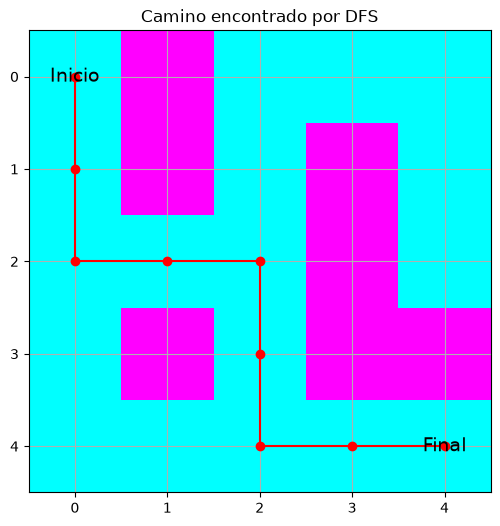

In [96]:
mostrar_laberinto(
    laberinto,
    resultado_dfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por DFS"
)

## 1.5 Comparación experimental

In [97]:
comparacion = {
    "BFS": {
        "longitud_camino": len(resultado_bfs["camino"]) - 1,
        "explorados": resultado_bfs["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs["camino"]) - 1,
        "explorados": resultado_dfs["explorados"],
    },
}

comparacion

{'BFS': {'longitud_camino': 8, 'explorados': 16},
 'DFS': {'longitud_camino': 8, 'explorados': 18}}

# 2. Solución del taller


## 2.1 Punto 1


In [98]:
MOVIMIENTOS_ORIGINAL = list(MOVIMIENTOS)

# Aqui como se comportan tanto BFS como DFS con los movimientos originales
bfs_original = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
dfs_original = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)


In [99]:

# Modificación del orden de los movimientos
MOVIMIENTOS[:] = [(0, -1), (-1, 0), (0, 1), (1, 0)]  # izquierda, arriba, derecha, abajo

# Comportamiento con el orden previamente modificado
bfs_modificado = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
dfs_modificado = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)


In [100]:

# Regreso al orden original de la lista de tuplas de movimientos
MOVIMIENTOS[:] = MOVIMIENTOS_ORIGINAL

comparacion_punto1 = {
    "Orden original ((abajo, arriba, derecha, izquierda))": {
        "BFS": {
            "longitud": len(bfs_original["camino"]) - 1,
            "explorados": bfs_original["explorados"],
        },
        "DFS": {
            "longitud": len(dfs_original["camino"]) - 1,
            "explorados": dfs_original["explorados"],
        },
    },
    "Orden modificado ((izquierda, arriba, derecha, abajo))": {
        "BFS": {
            "longitud": len(bfs_modificado["camino"]) - 1,
            "explorados": bfs_modificado["explorados"],
        },
        "DFS": {
            "longitud": len(dfs_modificado["camino"]) - 1,
            "explorados": dfs_modificado["explorados"],
        },
    },
}

comparacion_punto1

{'Orden original ((abajo, arriba, derecha, izquierda))': {'BFS': {'longitud': 8,
   'explorados': 16},
  'DFS': {'longitud': 8, 'explorados': 18}},
 'Orden modificado ((izquierda, arriba, derecha, abajo))': {'BFS': {'longitud': 8,
   'explorados': 17},
  'DFS': {'longitud': 8, 'explorados': 11}}}

### 2.1.1 Visualización de los resultados con movimientos modificados

Los gráficos siguientes muestran los caminos que encuentran **BFS y DFS después de haber modificado el orden de las tuplas de `MOVIMIENTOS`**.

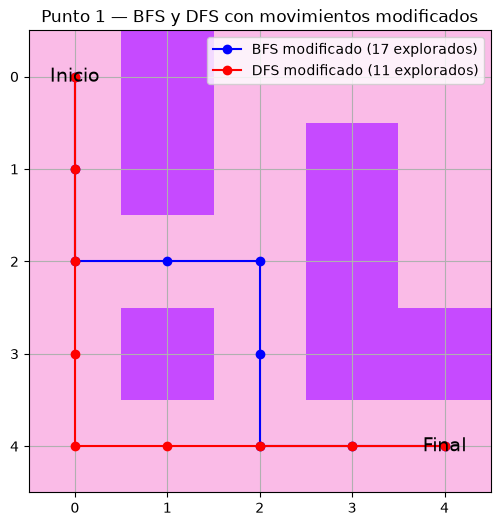

In [101]:
import matplotlib.colors as mcolors


colores_pastel = mcolors.ListedColormap(["#FABBE7", "#C64AFF"])


def mostrar_caminos_juntos(laberinto, caminos, inicio, objetivo, titulo):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(laberinto, cmap=colores_pastel)

    for nombre, (camino, color) in caminos.items():
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, color=color, marker="o", label=nombre)

    if inicio is not None:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=14)
    if objetivo is not None:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=14)

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    ax.legend()
    plt.show()


mostrar_caminos_juntos(
    laberinto,
    {
        "BFS modificado (17 explorados)": (bfs_modificado["camino"], "blue"),
        "DFS modificado (11 explorados)": (dfs_modificado["camino"], "red"),
    },
    INICIO,
    OBJETIVO,
    "Punto 1 — BFS y DFS con movimientos modificados"
)

**Observación del punto 1**

Ambos tienen 8 movimientos (la mínima), así que aquí la diferencia de orden no se nota en la forma del camino, **sí en el esfuerzo**: DFS con el orden modificado explora solo 11 estados frente a 17 de BFS.

 Modificar el orden de los movimientos no cambia la **existencia** de la solución, pero sí el **esfuerzo de búsqueda** de DFS y el orden en que se descubren los estados; BFS, por su estrategia por niveles, garantiza la ruta mínima independientemente del orden de `MOVIMIENTOS`.

## 2.2 Punto 2 — Laberinto 10×10: comparar BFS y DFS

Reutilización de `bfs_camino_laberinto` y `dfs_camino_laberinto` definidas antes, y comparación de **longitud del camino** y **estados explorados**.

In [102]:
laberinto10 = [
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

INICIO10 = (0, 0)
OBJETIVO10 = (9, 9)

resultado_bfs10 = bfs_camino_laberinto(laberinto10, INICIO10, OBJETIVO10)
resultado_dfs10 = dfs_camino_laberinto(laberinto10, INICIO10, OBJETIVO10)

comparacion_punto2 = {
    "BFS": {
        "longitud_camino": len(resultado_bfs10["camino"]) - 1,
        "explorados": resultado_bfs10["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs10["camino"]) - 1,
        "explorados": resultado_dfs10["explorados"],
    },
}

comparacion_punto2

{'BFS': {'longitud_camino': 18, 'explorados': 46},
 'DFS': {'longitud_camino': 34, 'explorados': 61}}

## 2.2.1 Visualización de los caminos encontrados

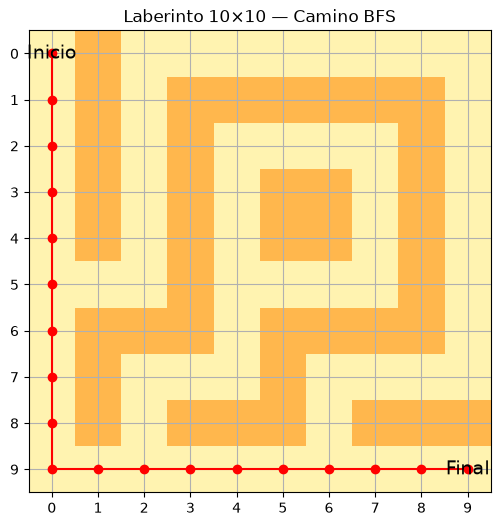

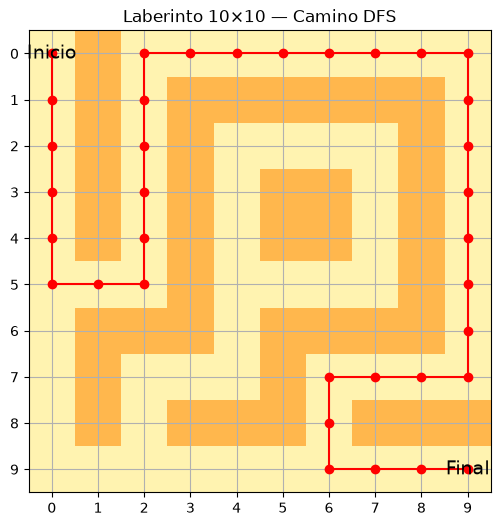

In [ ]:
import matplotlib.colors as mcolors

#Cambio de colores para distinguir cada laberinto
colores_pastel10 = mcolors.ListedColormap(["#FFF3B0", "#FFB74D"])

mostrar_laberinto(
    laberinto10,
    resultado_bfs10["camino"],
    INICIO10,
    OBJETIVO10,
    "Laberinto 10×10 — Camino BFS",
    cmap=colores_pastel10
)

mostrar_laberinto(
    laberinto10,
    resultado_dfs10["camino"],
    INICIO10,
    OBJETIVO10,
    "Laberinto 10×10 — Camino DFS",
    cmap=colores_pastel10
)

# Interpretación gráficos

Esto ilustra que, aunque **DFS puede requerir menos memoria** (pilas por ramas), **no garantiza la ruta más corta**, y la cantidad de estados explorados depende del orden de movimientos. BFS garantiza la ruta mínima porque explora por niveles.